# Drive-by Monitoring of Railway Bridges for Gradual Scour Damage Identification in Deep Foundations

In [ ]:
import hashlib
import json
import math
import os
import random
import time
from dataclasses import asdict, dataclass, field
from itertools import product
from typing import Any, Dict, List, Optional

# Data handling and numerical operations
import numpy as np
from scipy.io import loadmat
from scipy.stats import lognorm, norm

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
from torch import Tensor
from torch.optim.optimizer import Optimizer, required
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split

# Visualization
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

# Transformer models and utilities
from linformer import Linformer
from pytorch_wavelets import DWT1D
from torchinfo import summary
from transformers import BigBirdConfig, BigBirdModel, LongformerConfig, LongformerModel

In [ ]:
# https://github.com/generativeai-tue/vsgd
class VSGD(Optimizer):
    def __init__(
        self,
        params: required,
        ghattg: float = 30.0,
        ps: float = 1e-8,
        tau1: float = 0.81,
        tau2: float = 0.9,
        lr: float = 0.1,
        weight_decay: float = 0.0,
        eps: float = 1e-8,
    ):
        """
        Args:
            ghattg: prior variance ratio between ghat and g,
                Var(ghat_t-g_t)/Var(g_t-g_{t-1}).
            ps: piror strength.
            tau1: remember rate for the gamma parameters of g
            tau2: remember rate for the gamma parameter of ghat
            lr: learning rate.
            weight_decay (float): weight decay coefficient (default: 0.0)
        """

        if not 0.0 <= weight_decay:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")
        defaults = dict(
            ghattg=ghattg,
            ps=ps,
            tau1=tau1,
            tau2=tau2,
            lr=lr,
            weight_decay=weight_decay,
            eps=eps,
        )
        super().__init__(params, defaults)

    def __setstate__(self, state):
        super(VSGD, self).__setstate__(state)

    def step(self, closure=None):
        """Performs a single optimization step.

        Args:
            closure (Callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        # self._cuda_graph_capture_health_check()

        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            params_with_grad = []
            grads = []
            mug_list = []
            step_list = []
            pa2_list = []
            pbg2_list = []
            pbhg2_list = []
            bg_list = []
            bhg_list = []

            self._init_group(
                group,
                params_with_grad,
                grads,
                mug_list,
                step_list,
                pa2_list,
                pbg2_list,
                pbhg2_list,
                bg_list,
                bhg_list,
                group["ghattg"],
                group["ps"],
            )

            vsgd(
                params_with_grad,
                grads,
                mug_list,
                step_list,
                pa2_list,
                pbg2_list,
                pbhg2_list,
                bg_list,
                bhg_list,
                group["tau1"],
                group["tau2"],
                group["lr"],
                group["weight_decay"],
                group["eps"],
            )

        return loss

    def _init_group(
        self,
        group,
        params_with_grad: List[Tensor],
        grads: List[Tensor],
        mug_list: List,
        step_list: List,
        pa2_list: List,
        pbg2_list: List,
        pbhg2_list: List,
        bg_list: List,
        bhg_list: List,
        ghattg: float,
        ps: float,
    ):
        for p in group["params"]:
            if p.grad is None:
                continue
            params_with_grad.append(p)

            grads.append(p.grad)
            state = self.state[p]

            # State initialization
            if len(state) == 0:
                for k in ["mug", "bg", "bhg"]:
                    # set a non zero small number to represent prior ignornance
                    state[k] = torch.zeros_like(p, memory_format=torch.preserve_format)
                # initialize 2*a_0 and 2*b_0 as constants
                state["pa2"] = torch.tensor(2.0 * ps + 1.0 + 1e-4)
                state["pbg2"] = torch.tensor(2.0 * ps)
                state["pbhg2"] = torch.tensor(2.0 * ghattg * ps)
                state["step"] = torch.tensor(0.0)

            mug_list.append(state["mug"])
            bg_list.append(state["bg"])
            bhg_list.append(state["bhg"])
            step_list.append(state["step"])
            pa2_list.append(state["pa2"])
            pbg2_list.append(state["pbg2"])
            pbhg2_list.append(state["pbhg2"])

    def get_current_beta1_estimate(self) -> Tensor:
        betas = []
        for group in self.param_groups:
            for p in group["params"]:
                state = self.state[p]
                bg = state["bg"]
                bhg = state["bhg"]
                betas.append((bhg / (bg + bhg)).data)
        return betas


def vsgd(
    params_with_grad: List[Tensor],
    grads: List[Tensor],
    mug_list: List[Tensor],
    step_list: List[Tensor],
    pa2_list: List[Tensor],
    pbg2_list: List[Tensor],
    pbhg2_list: List[Tensor],
    bg_list: List[Tensor],
    bhg_list: List[Tensor],
    tau1: float,
    tau2: float,
    lr: float,
    weight_decay: float,
    eps: float,
):
    for i, param in enumerate(params_with_grad):
        ghat = grads[i]
        mug = mug_list[i]
        mug1 = torch.clone(mug)
        step = step_list[i]
        step += 1
        pa2 = pa2_list[i]
        pbg2 = pbg2_list[i]
        pbhg2 = pbhg2_list[i]
        bg = bg_list[i]
        bhg = bhg_list[i]
        # weight decay following AdamW
        param.data.mul_(1 - lr * weight_decay)

        # variances of g and ghat
        if step == 1.0:
            sg = pbg2 / (pa2 - 1.0)
            shg = pbhg2 / (pa2 - 1.0)
        else:
            sg = bg / pa2
            shg = bhg / pa2
        # update muh, mug, Sigg and Sigh
        mug.copy_((ghat * sg + mug1 * shg) / (sg + shg))
        sigg = sg * shg / (sg + shg)

        # update 2*b
        mug_sq = sigg + mug**2
        bg2 = pbg2 + mug_sq - 2.0 * mug * mug1 + mug1**2
        bhg2 = pbhg2 + mug_sq - 2.0 * ghat * mug + ghat**2

        rho1 = step ** (-tau1)
        rho2 = step ** (-tau2)
        bg.mul_(1.0 - rho1).add_(bg2, alpha=rho1)
        bhg.mul_(1.0 - rho2).add_(bhg2, alpha=rho2)

        # update param
        param.data.add_(lr / (torch.sqrt(mug_sq) + eps) * mug, alpha=-1.0)

## Dataset: Vehicle-Structure Interaction (VSI) with Scour Damage

This dataset contains reorganized acceleration data obtained from numerical simulations of the Canelas railway bridge (Portugal) under different scour conditions.

In summary, sensors are installed on the vehicles to capture the response from the vehicle-structure interaction. These responses consist of time series data obtained as the vehicle passes over the structure.

Simulations were performed for different damage scenarios (scour, which is the erosion of the foundation soil).

The objective is to detect damage using an anomaly detection approach. An autoencoder is trained exclusively on data from the healthy structure (*hscour0*). When presented with new data, the model's reconstruction error is calculated. A significantly high reconstruction error suggests that the new data does not conform to the learned patterns of a healthy structure, thus indicating probable damage. In a real-world scenario following an event like a flood, the bridge's condition would be unknown. By analyzing the reconstruction error from new vehicle passages, this model can infer the likely health of the structure.

**Damage scenarios:**
- *hscour0* → Bridge with no scour (healthy)
    - Contains data from 93 simulated vehicle passages.

- *hscour1* → Bridge with 1 meter of scour (slight damage)
    - Contains data from 50 simulated vehicle passages.

- *hscour3* → Bridge with 3 meters of scour (medium damage)
    - Contains data from 50 simulated vehicle passages.

**Data structure**

Each *.mat* file contains a single variable named Data_Pos, with the following dimensions:

*Data_Pos*: $[9 \times 2800 \times n_{passages}]$, where:
- 9 is the combination of sensors (3 vehicles × 3 degrees of freedom); and
- 2800 is the number of acceleration samples per passage.

**Degrees of Freedom (DoFs):**
- *UY* – Lateral displacement
- *UZ* – Vertical displacement
- *ROTY* – Rotation around the lateral axis

**Vehicles analyzed:**
- *Veh1* – First vehicle
- *Veh4* – Intermediate vehicle
- *Veh6* – Last vehicle

**Channel order:**
- 1 $\rightarrow$ *UY_Veh1*
- 2 $\rightarrow$ *UZ_Veh1*
- 3 $\rightarrow$ *ROTY_Veh1*
- 4 $\rightarrow$ *UY_Veh4*
- 5 $\rightarrow$ *UZ_Veh4*
- 6 $\rightarrow$ *ROTY_Veh4*
- 7 $\rightarrow$ *UY_Veh6*
- 8 $\rightarrow$ *UZ_Veh6*
- 9 $\rightarrow$ *ROTY_Veh6*

Since the data comes from numerical simulations, there are no outliers or missing data. This differs from a real-world scenario, where interference in the data acquisition and transmission systems can occur.

## Detailed simulation information

### Numerical Model of the Canelas Railway Bridge
The discretization of the numerical model is presented in the image below:

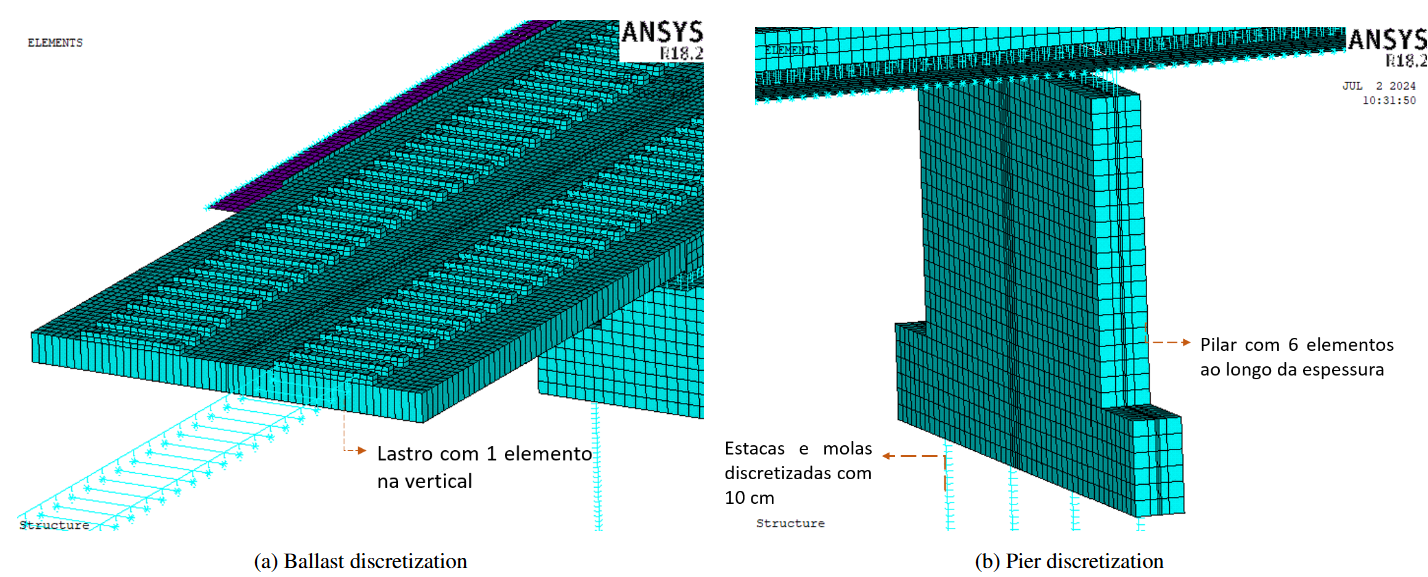

#### Operational variabilities
The operational variabilities introduced into the simulations are listed in the table below:

| **Variability**                         | **Unit** | **Mean**   | **SD**    |
|-----------------------------------------|----------|------------|-----------|
| Temperature                             | °C       | 15         | 10        |
| Car body mass                           | kg       | 37443      | 3744      |
| Primary suspension stiffness Ux         | N/m      | 44981000   | 44981     |
| Primary suspension stiffness Uy         | N/m      | 30948200   | 30948     |
| Primary suspension stiffness Uz         | N/m      | 1652820    | 165382    |
| Secondary suspension stiffness Ux       | N/m      | 4905000    | 490500    |
| Secondary suspension stiffness Uy       | N/m      | 2500000    | 250000    |
| Secondary suspension stiffness Uz       | N/m      | 734832     | 73483     |
| Train speed                             | km/h     | 175        | 25        |
| Measurement noise                       | %        | 0          | 5         |

### Scour (Erosion of foundation soil)

#### Scour depth
Local soil erosion at the piles for the complex pier foundations is modeled according to the image below, where the total scour ($y_s$) is given by the sum: $y_s = y_{sps} + y_{spc} + y_{spg}$. The piles are 40 meters deep.

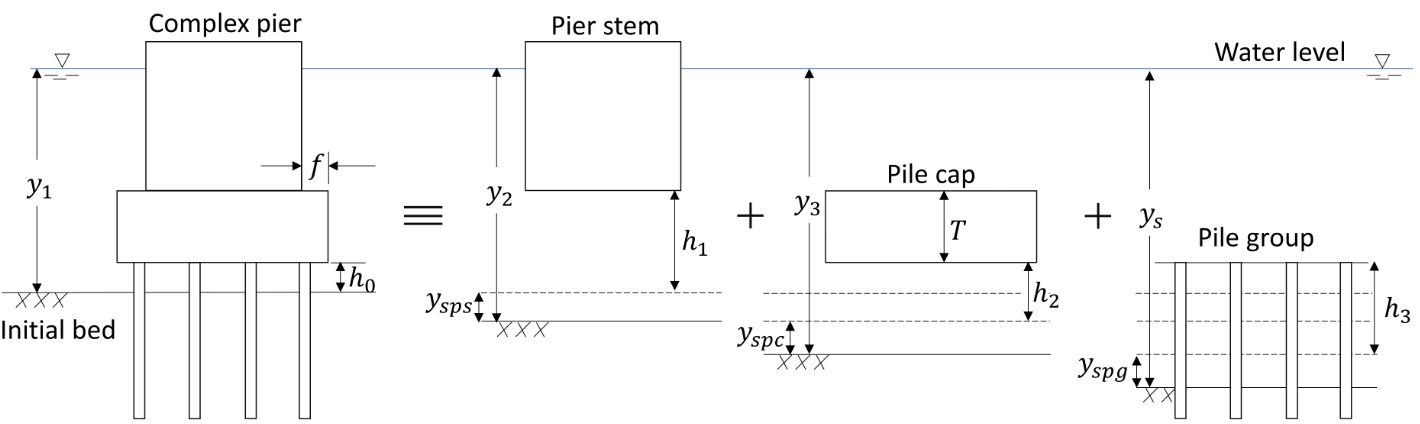

#### Sensitivity analysis of pile displacement due to scour
The displacements of a single pile under each scour scenario are illustrated in the graphs below. This analysis considered a horizontal load of 5000 kN applied at the top of the pile.

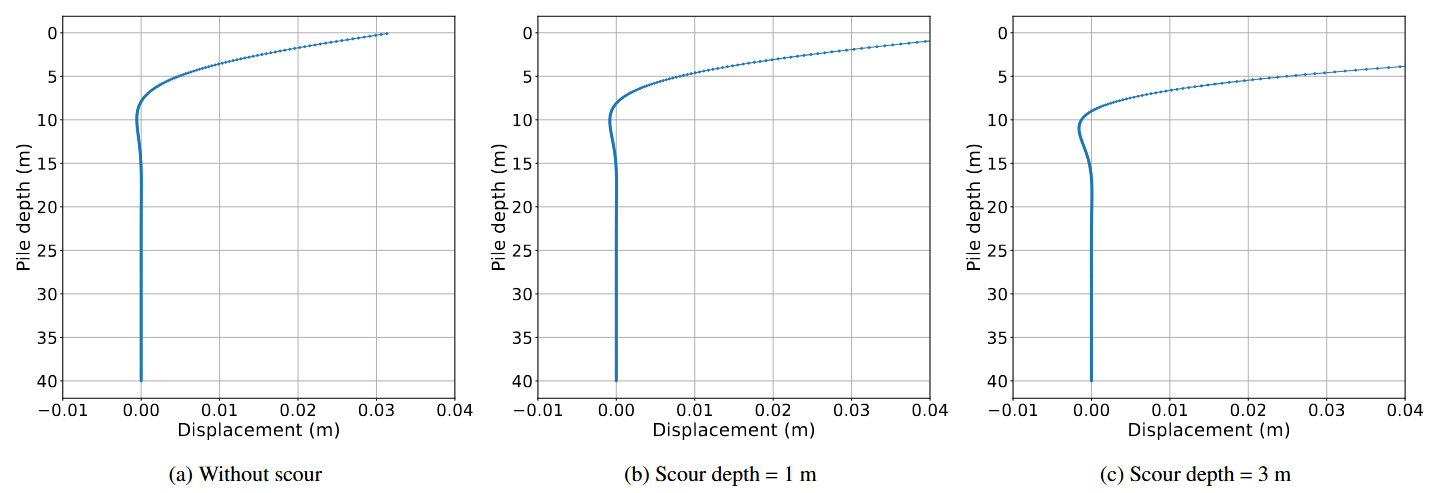

### Sensor locations
The data collected from the numerical model originates from vehicles 1, 4, and 6 of the train consist:

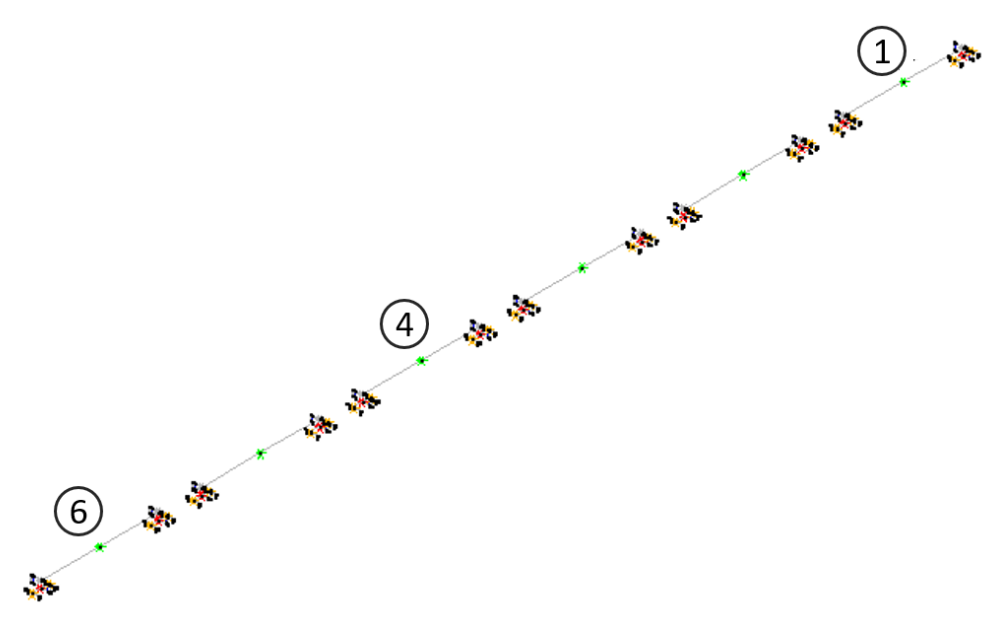

These vehicle locations simulate the placement of sensors that would be used in a field application, positioned on each vehicle as follows:

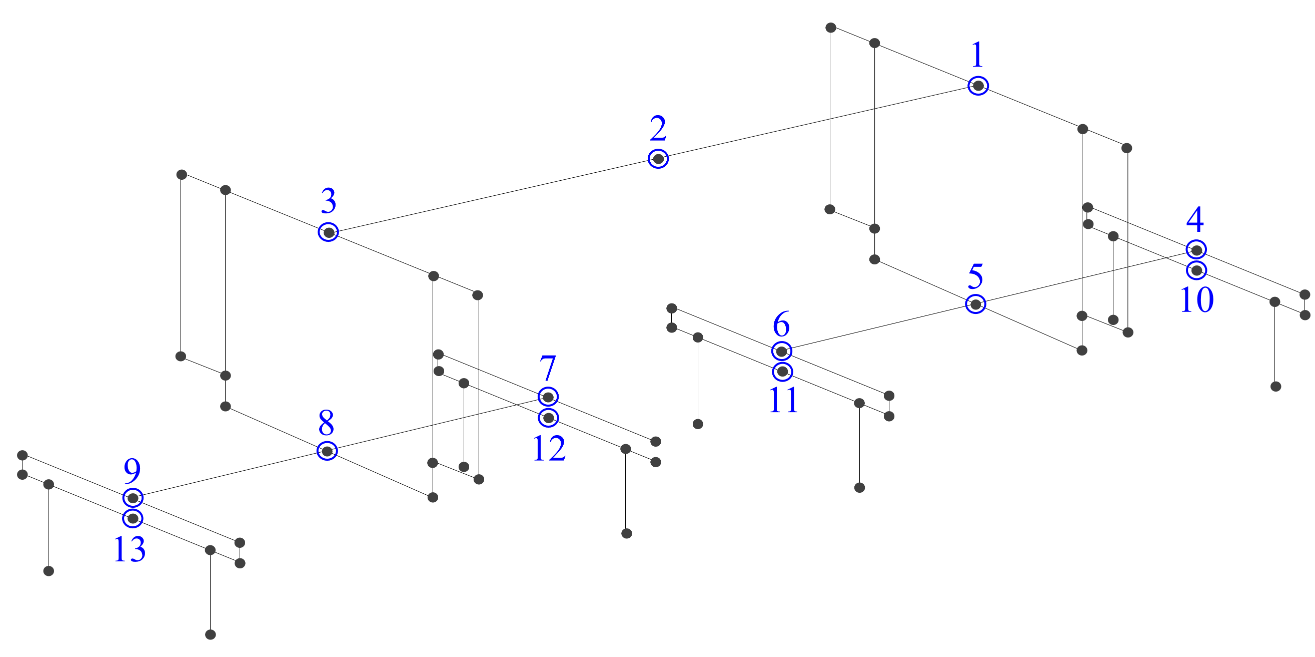



## Anomaly detection with Autoenconder
- using only one channel
- 3 scenarios: *hscour0*, *hscour1*, *hscour3*
- 50 passages per scenario

### Parameters

In [ ]:
@dataclass
class DataConfig:
    """Configuration for dataset loading and experiment setup."""
    pos_sensor: str = 'CB_Front'
    # Corrected index for Veh1 Vertical Acceleration (UZ)
    dof_index: int = 8
    n_passes: int = 50
    n_passes_baseline: int = 100
    scenarios: List[str] = field(default_factory=lambda: ['hscour0', 'hscour1', 'hscour3'])
    scenario_names: List[str] = field(default_factory=lambda: ['Baseline', 'Scour 1m', 'Scour 3m'])
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

# Create an instance of the configuration
data_config = DataConfig()

In [ ]:
def set_seed(seed: int):
    """
    Sets the random seeds for reproducibility.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Configure for deterministic operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call the function at the start of your script
SEED = 42
set_seed(SEED)

#### Load dataset

In [ ]:
def load_vertical_acceleration(config: DataConfig) -> List[np.ndarray]:
    """
    Loads vertical acceleration data based on the provided configuration.
    
    Args:
        config (DataConfig): The dataclass containing dataset parameters.
        
    Returns:
        A list of numpy arrays, where each array corresponds to a scenario.
    """
    all_data = []
    for scenario in config.scenarios:
        # Use attributes from the config object
        fn = f'Data_Pos_{config.pos_sensor}_{scenario}.mat'
        mat = loadmat(fn)
        data_pos = mat['Data_Pos']
        
        # Use attributes from the config object
        if scenario == "hscour0":
            uz_data = data_pos[config.dof_index, :, :config.n_passes_baseline]
        else:
            uz_data = data_pos[config.dof_index, :, :config.n_passes]
        samples = uz_data.T
        all_data.append(samples)
        
    return all_data

In [ ]:
all_data = load_vertical_acceleration(data_config)

## EDA

Plotting a few sample passages from each scenario to see if there are any visual differences.

In [ ]:
BRIDGE_LENGTH_M = 28
N_SAMPLES = all_data[0].shape[1]
position_axis = np.linspace(0, BRIDGE_LENGTH_M, N_SAMPLES)

# Create a figure with 3 subplots, sharing the x-axis
fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True)
fig.suptitle('Comparison of Random Signals Across Scenarios', fontsize=20, y=0.95)

# Select 3 unique random passage indices from each scenario
num_passages_per_scenario = [data.shape[0] for data in all_data]
random_indices = [
    np.random.choice(num_passages, 3, replace=False) for num_passages in num_passages_per_scenario
]

# Loop through the 3 sample plots
for i in range(3):
    ax = axes[i]
    # Loop through each scenario (Baseline, Scour 1m, Scour 3m)
    for j, scenario_data in enumerate(all_data):
        # Get the specific random passage for this plot
        passage_index = random_indices[j][i]
        
        ax.plot(
            position_axis,
            scenario_data[passage_index, :],
            label=f'{data_config.scenario_names[j]} (Passage #{passage_index})',
            alpha=0.8
        )
    
    ax.set_title(f'Random Sample Comparison #{i+1}', fontsize=14)
    ax.set_ylabel('Vertical Acceleration (m/s²)', fontsize=12)
    ax.legend()
    ax.grid(True)

# Set the shared x-axis label on the last plot
axes[-1].set_xlabel('Position Along Bridge (m)', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

In [ ]:
plot_data = []
for i, scenario_data in enumerate(all_data):
    for passage in scenario_data:
        for value in passage:
            plot_data.append({
                'Scenario': data_config.scenario_names[i],
                'Acceleration': value
            })

import pandas as pd
df_plot = pd.DataFrame(plot_data)

# Create the violin plot
fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(x='Scenario', y='Acceleration', data=df_plot, ax=ax, hue='Scenario', palette='viridis')

ax.set_title('Distribution of Acceleration Values per Scenario', fontsize=16)
ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Acceleration (m/s²)', fontsize=12)
plt.show()

For vibration data, the frequency domain is often where the most valuable information lies. Damage can change the natural frequencies of the bridge. Down below the average Power Spectral Density (PSD) is computed for each scenario.

In [ ]:
fig, ax = plt.subplots(figsize=(15, 7))

# The distance between spatial samples
sample_spacing = BRIDGE_LENGTH_M / (N_SAMPLES - 1)

for i, scenario_data in enumerate(all_data):
    fft_results = np.fft.rfft(scenario_data, axis=1)
    power_spectrum = np.abs(fft_results)**2
    avg_power_spectrum = np.mean(power_spectrum, axis=0)
    
    wavenumber_axis = np.fft.rfftfreq(N_SAMPLES, d=sample_spacing)
    
    ax.plot(wavenumber_axis, avg_power_spectrum, label=data_config.scenario_names[i], alpha=0.8)

ax.set_title('Average Spatial Power Spectrum per Scenario', fontsize=16)
ax.set_xlabel('Spatial Frequency / Wavenumber (cycles/meter)', fontsize=12)
ax.set_ylabel('Power', fontsize=12)
ax.set_yscale('log')
ax.set_xlim(0, 0.5)  # Zoom in on a relevant wavenumber range
ax.legend()
plt.show()

Indeed, the EDA showed that the PSD was revealing and that it is hard to distinguish only by visualizing the signals on top of each other. The violin plots do not reveal much too.

The presence of scour damage consistently increases the energy of the signal's spatial frequencies.

The problem seems solveable and preprocessors like Wavelet or Fourier may help.

## Ablation study

### Goal of the study
The goal is to evaluate how different deep learning components affect the autoencoder's performance in detecting scour damage in a railway bridge using signals from accelerometers installed in the vehicle passin over the bridge. Research questions:
1. Which architectural family (MLP, CNN, RNN, or Transformer) is the most effective for the task at hand?
2. Does signal preprocessing in the frequency or wavelet domain improve model performance?
3. Does the probabilistic latent space of Variational Autoencoder (VAE) offer an advantage over a standard Autoencoder (AE)?

### Experimental setup
Various combinations of encoders, decoders, and preprocessors are tested. The baseline model used in previous researches by the research group in which the student is in used a Multi-Layer Perceptron (MLP) AE with no preprocessing, which serves as a benchmark for all other configurations. Also, the dataset used is completely new, originated from very expensive numerical simulations. Therefore, any gain in changing the base architecture is welcome, especially because there are real-world data coming from passages over a railway bridge before and after its maintenance, and these tests may help dealing with the assessment of damage in the real-world.

#### Architectures
The following components are systematically varied:

- **Encoder/Decoder architectures:** symmetric pairs are employed to assess the effectiveness of each approach:
    - **MLP:** a fully-connected baseline that treats the entire signal as a single flat vector, learning global, non-sequential patterns from the data;
    - **Convolutional (CNN):** designed to learn local spatial patterns and recurring motifs (like specific shapes or oscillations) in the signal using 1D convolutional kernels that act as sliding filters;
    - **LSTM:** a recurrent approach to model sequential dependencies by processing the signal step-by-step from start to finish, using internal memory gates to capture sequential dependencies and spatial context; and
    - **Transformers:** to leverage attention-based mechanisms for capturing complex, long-range dependencies across the entire bridge length. This architecture efficiently weighs the importance of every point in the sequence relative to every other point.
- **Signal preprocessors:** to test the impact of the input data representation:
    - **Fourier transform:** to learn directly from the signal's spatial frequencies, allowing the model to learn directly from the dominant wavenumbers;
    - **Wavelet transform:** to provide a representation that captures both frequency and positional information, allowing the model to see what patterns exist and where they occur along the bridge; and
    - **Time2Vec:** learns a vector representation of position itself. This provides the model with an explicit, continuous understanding of both linear progression and periodicities along the bridge's length. This preprocessor is tested only with sequence-aware models, such as LSTM and Transformers. Time2Vec breaks the position down into a linear component and a periodic (sinusoidal) component. The final Time2Vec vector is created by concatenating the single linear component with the outputs of all the sinusoidal components.
        - The linear component is a learnable function $\omega\tau + \phi$ of the position that intends to capture the progression and scale of the data. It helps the model understand time or position.
        - The periodic components uses multiple sine functions with learnable frequencies and phase shifts $\mathcal{F}(\omega_i\tau + \phi_i)$. Each sine wave can capture a different cyclical or recurring pattern in the data. It may capture repeating patterns related to the sleepers or longer wave associated to the bridge's overall deflection shape.
- **Model type:** for each architectural combination, two variants are tested:
    - **Standard AE:** a deterministic model focused purely on minimizing reconstruction error; and
    - **Variational Autoencoder (VAE):** a probabilistic generative model that may provide a better-structured latent space for anomaly detection. Its difference with the basic AE is the latent space. Instead of mapping an input to a single point, it maps the input to a probability distribution, specifically a Gaussian one. The vector $\mu$ (mean) defines the center of the distribution of that input, while the log-variance, $logvar$, defines the uncertainty or spread of the distribution. The model samples a random point $z$ from this learned distribution and passes that sample to the decoder. The Kullback-Leibler Divergence (KLD) acts as a powerful regularizer, by forcing all of these learned distribtuions to stay close to a standard normal distribution. This prevents the model from creating gaps, because distributions for similar inputs are forced to overlap, creating a continuous latent space. For this problem, damaged data might not have a well-defined distribution to map to, resulting in a higher reconstruction error, making it easier to detect different damage scenarios.

The hyperparameters are fixed for a fair comparison. 

In [ ]:
@dataclass
class ModelConfig:
    """A dataclass to hold all model and training configurations."""
    # Core architecture
    input_dim: int
    latent_dim: int
    encoder_type: str
    decoder_type: str
    
    # Preprocessing and model variants
    preprocessor: Optional[str] = None
    vae: bool = False
    
    # Hyperparameters for specific architectures
    n_layers: int = 2
    n_heads: int = 4
    dropout: float = 0.1
    use_batchnorm: bool = False
    
    # CNN architecture parameters
    cnn_out_channels: List[int] = field(default_factory=lambda: [16, 32, 64])
    cnn_kernel_sizes: List[int] = field(default_factory=lambda: [7, 5, 3])
    cnn_strides: List[int] = field(default_factory=lambda: [2, 2, 2])
    
    # For the RNNs
    rnn_hidden_size: int = 128
    
    # Note: 'seq_len' can often be inferred from 'input_dim'
    seq_len: Optional[int] = None
    hidden_dims: List[int] = field(default_factory=lambda: [64, 32])

    
    def __post_init__(self):
        # Set seq_len if not provided
        if self.seq_len is None:
            self.seq_len = self.input_dim

@dataclass
class TrainingConfig:
    lr: float = 1e-3
    batch_size: int = 32
    epochs: int = 100
    patience: int = 10
    criterion: str = "mae"
    optimizer: str = "adam"
    weight_decay: float = 0.0
    min_delta: float = 1e-4
    use_amp: bool = False
    lr_scheduler: Optional[str] = None
    lr_scheduler_params: Dict[str, Any] = field(default_factory=dict)
    lambda_kl: float = 0.1

In [ ]:
class FourierPreprocessor(nn.Module):
    def __init__(self, original_input_dim: int):
        super().__init__()
        self.original_input_dim = original_input_dim
    
    def forward(self, x):
        # Take the magnitude of the real FFT
        return torch.fft.rfft(x, dim=1).abs()

    def get_output_dim(self):
        # rfft returns a tensor of size (N/2 + 1)
        return self.original_input_dim // 2 + 1
    
    def get_feature_dim(self):
        return 1

class WaveletPreprocessor(nn.Module):
    def __init__(self, original_input_dim: int, wavelet='db1', level=1):
        super().__init__()
        # The DWT object is instantiated once and works on the GPU
        self.dwt = DWT1D(wave=wavelet, J=level, mode='symmetric')
        
        # Calculate output dimension based on one forward pass
        # This is much cleaner now and stays on the device
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, original_input_dim) # DWT expects (N, C, L)
            cA, _ = self.dwt(dummy_input)
            self.transformed_dim = cA.shape[-1] # Get length from the output tensor

    def forward(self, x):
        # x is expected to be (Batch, Length)
        # Add a channel dimension for the DWT layer
        x = x.unsqueeze(1) # (B, 1, L)
        
        # This single line replaces the entire loop and runs on the GPU
        cA, _ = self.dwt(x) # cD are the detail coefficients, ignored here
        
        # Remove the channel dimension for the output
        return cA.squeeze(1) # (B, L_new)

    def get_output_dim(self):
        return self.transformed_dim
        
    def get_feature_dim(self):
        return 1

class Time2Vec(nn.Module):
    def __init__(self, seq_len: int, embedding_dim: int):
        super().__init__()
        if embedding_dim % 2 != 0:
            raise ValueError("Embedding dimension must be even for Time2Vec.")
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim
        self.weights_linear = nn.Parameter(torch.randn(1, self.embedding_dim // 2))
        self.bias_linear = nn.Parameter(torch.randn(1, self.embedding_dim // 2))
        self.weights_periodic = nn.Parameter(torch.randn(1, self.embedding_dim // 2))
        self.bias_periodic = nn.Parameter(torch.randn(1, self.embedding_dim // 2))

    def forward(self, x):
        # Input x is used for shape and device, but its values are replaced.
        t = torch.arange(x.size(1), device=x.device, dtype=x.dtype).unsqueeze(0).unsqueeze(-1)  # (1, seq_len, 1)
        
        linear_part = torch.matmul(t, self.weights_linear) + self.bias_linear
        periodic_part = torch.sin(torch.matmul(t, self.weights_periodic) + self.bias_periodic)
        
        # Concatenate original input with its time embedding
        return torch.cat([x.unsqueeze(-1), linear_part.repeat(x.size(0), 1, 1), periodic_part.repeat(x.size(0), 1, 1)], dim=-1)

    def get_output_dim(self):
        # The sequence length remains the same
        return self.seq_len

    def get_feature_dim(self):
        # Original feature (1) + linear features + periodic features
        return 1 + self.embedding_dim

In [ ]:
class MLPBlock(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim=None, activation=nn.ReLU,
                 final_activation=None, use_batchnorm=False, dropout=0.0):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))

        if output_dim:
            last_dim = dims[-1] if hidden_dims else input_dim
            layers.append(nn.Linear(last_dim, output_dim))
            if final_activation:
                layers.append(final_activation())

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class EncoderConv(nn.Module):
    def __init__(self, latent_dim, out_channels, kernel_sizes, strides,
                 activation=nn.ReLU, use_batchnorm=False, dropout=0.0):
        super().__init__()
        layers = []
        in_channels = 1
        for i in range(len(out_channels)):
            padding = (kernel_sizes[i] - 1) // 2
            layers.append(nn.Conv1d(
                in_channels, out_channels[i], kernel_sizes[i], strides[i], padding
            ))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(out_channels[i]))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_channels = out_channels[i]
        
        layers.append(nn.AdaptiveAvgPool1d(1))
        self.conv = nn.Sequential(*layers)
        self.fc = nn.Linear(out_channels[-1], latent_dim)

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
        x = self.conv(x).squeeze(-1)
        return self.fc(x)

class DecoderConv(nn.Module):
    def __init__(self, input_dim, latent_dim, out_channels, kernel_sizes, strides,
                 activation=nn.ReLU, use_batchnorm=False, dropout=0.0):
        super().__init__()
        self.input_dim = input_dim
        self.fc = nn.Linear(latent_dim, out_channels[-1])
        
        layers = []
        in_channels = out_channels[-1]
        for i in reversed(range(len(out_channels))):
            out_ch = out_channels[i-1] if i > 0 else 1
            layers.append(nn.ConvTranspose1d(
                in_channels, out_ch, kernel_sizes[i], strides[i],
                padding=(kernel_sizes[i] - 1) // 2,
                output_padding=strides[i] - 1
            ))
            if i > 0: # No regularization on the final output layer
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(out_ch))
                layers.append(activation())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
            in_channels = out_ch

        self.conv_transpose = nn.Sequential(*layers)

    def forward(self, z):
        x = self.fc(z).unsqueeze(-1)
        x = self.conv_transpose(x)
        x = x[:, :, :self.input_dim]
        return torch.sigmoid(x.squeeze(1))

class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, rnn_type='LSTM', dropout=0.0):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type.upper() == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, latent_dim)

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(-1)
        
        _, h = self.rnn(x)
        if isinstance(h, tuple): # For LSTM, h is (h_n, c_n)
            h = h[0]
        
        # Take the hidden state from the last layer
        last_layer_hidden_state = h[-1]
        return self.fc(last_layer_hidden_state)

class DecoderRNN(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_seq_len, rnn_type='LSTM', dropout=0.0):
        super().__init__()
        self.output_seq_len = output_seq_len
        self.input_proj = nn.Linear(latent_dim, hidden_size)
        rnn_cls = nn.LSTM if rnn_type.upper() == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, z):
        # Project and repeat the latent vector for each step of the output sequence
        z_proj = self.input_proj(z)
        z_repeated = z_proj.unsqueeze(1).repeat(1, self.output_seq_len, 1)
        
        out, _ = self.rnn(z_repeated)
        out = self.fc(out)
        return torch.sigmoid(out.squeeze(-1))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

class EncoderTransformer(nn.Module):
    def __init__(self, d_model, latent_dim, nhead, n_layers, dropout, input_feature_dim=1):
        super().__init__()
        self.input_proj = nn.Linear(input_feature_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pos_encoder = PositionalEncoding(d_model)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Linear(d_model, latent_dim)

    def forward(self, x):
        # x: (B, Seq_Len) or (B, Seq_Len, Features)
        if x.ndim == 2:
            x = x.unsqueeze(-1) # (B, Seq_Len, 1)
        
        x = self.input_proj(x) # (B, Seq_Len, d_model)
        x = self.pos_encoder(x)
        x = self.transformer(x) # (B, Seq_Len, d_model)
        x = x.transpose(1, 2) # (B, d_model, Seq_Len) for pooling
        x = self.pool(x).squeeze(-1) # (B, d_model)
        return self.proj(x)

class DecoderTransformer(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_seq_len, nhead, n_layers, dropout):
        super().__init__()
        self.output_seq_len = output_seq_len
        self.memory_proj = nn.Linear(latent_dim, hidden_dim)
        
        # A learnable query sequence that the decoder will transform
        self.tgt_embedding = nn.Parameter(torch.randn(1, output_seq_len, hidden_dim))
        self.pos_encoder = PositionalEncoding(hidden_dim)

        decoder_layer = nn.TransformerDecoderLayer(d_model=hidden_dim, nhead=nhead, dropout=dropout, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(hidden_dim, 1) # Output 1 feature per time step

    def forward(self, z):
        # z: (B, latent_dim)
        batch_size = z.size(0)
        
        # Project latent vector to serve as memory for the decoder
        memory = self.memory_proj(z).unsqueeze(1) # (B, 1, hidden_dim)

        # Prepare the target query sequence
        tgt = self.tgt_embedding.repeat(batch_size, 1, 1)
        tgt = self.pos_encoder(tgt)

        # Decode
        out = self.decoder(tgt=tgt, memory=memory) # (B, output_seq_len, hidden_dim)
        
        # Project to final output dimension
        out = self.output_proj(out) # (B, output_seq_len, 1)
        return torch.sigmoid(out.squeeze(-1)) # (B, output_seq_len)


class Transpose(nn.Module):
    """A module to transpose dimensions of a tensor."""
    def __init__(self, dim0, dim1):
        super().__init__()
        self.dim0 = dim0
        self.dim1 = dim1

    def forward(self, x):
        return x.transpose(self.dim0, self.dim1)

class Squeeze(nn.Module):
    """A module to squeeze a dimension of a tensor."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        return x.squeeze(self.dim)


class EncoderLinformer(nn.Module):
    """
    An efficient encoder using the Linformer module.
    """
    def __init__(self, input_dim, d_model, latent_dim, n_layers, n_heads, dropout):
        super().__init__()
        encoder_block = Linformer(
            dim=d_model,
            seq_len=input_dim,
            depth=n_layers,
            heads=n_heads,
            k=256,
            one_kv_head=True,
            dropout=dropout
        )

        # We wrap the Linformer and add pooling and projection
        self.model = nn.Sequential(
            encoder_block,
            Transpose(1, 2),  # Replaces lambda x: x.transpose(1, 2)
            nn.AdaptiveAvgPool1d(1),
            Squeeze(-1),      # Replaces lambda x: x.squeeze(-1)
            nn.Linear(d_model, latent_dim)
        )
        
        # We also need an initial projection to match d_model
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(-1) # (B, L, 1)
        
        x = self.input_proj(x)  # (B, L, d_model)
        x = self.pos_encoder(x) # Add positional info
        return self.model(x)


class EncoderLongformer(nn.Module):
    """
    An efficient encoder using the Longformer model from Hugging Face.
    """
    def __init__(self, input_dim, d_model, latent_dim, n_layers, n_heads, dropout):
        super().__init__()
        
        # 1. Create a configuration for the Longformer
        config = LongformerConfig(
            # FIX: Increase vocab_size to be greater than the default pad_token_id (1)
            vocab_size=2,
            max_position_embeddings=input_dim + 2, # Must be larger than seq_len
            hidden_size=d_model,
            num_hidden_layers=n_layers,
            num_attention_heads=n_heads,
            attention_window=256,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout
        )
        
        # 2. Instantiate the Longformer model from the configuration
        self.longformer = LongformerModel(config, add_pooling_layer=False)
        
        # 3. Add our standard pooling and projection head
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Linear(d_model, latent_dim)

    def forward(self, x):
        # Longformer expects a different input shape: (Batch, Seq_Len) of integer IDs
        # We adapt our float input by simply passing it through the embeddings
        # The embeddings layer is just a lookup table, so we don't need a real vocab
        
        # Get the embedding layer from the Longformer model
        embedding_layer = self.longformer.get_input_embeddings()
        
        # Project our float tensor into the embedding space
        # x is (B, L), unsqueeze to (B, L, 1) and project to (B, L, d_model)
        if x.ndim == 2:
            x = x.unsqueeze(-1)
        
        # A simple linear projection can stand in for a token embedding
        # (This part is a slight simplification; a more complex model might use patching)
        x_emb = torch.matmul(x, embedding_layer.weight.T[:,:1].T)

        # Pass through the Longformer
        outputs = self.longformer(inputs_embeds=x_emb)
        sequence_output = outputs.last_hidden_state
        
        # Pool and project to get the latent vector
        pooled_output = self.pool(sequence_output.transpose(1, 2)).squeeze(-1)
        return self.proj(pooled_output)


class EncoderBigBird(nn.Module):
    """
    An efficient encoder using the BigBird model from Hugging Face.
    """
    def __init__(self, input_dim, d_model, latent_dim, n_layers, n_heads, dropout):
        super().__init__()
        
        # 1. Create a configuration for BigBird
        config = BigBirdConfig(
            vocab_size=1, # Dummy value
            max_position_embeddings=input_dim,
            hidden_size=d_model,
            num_hidden_layers=n_layers,
            num_attention_heads=n_heads,
            attention_type="block_sparse", # This is BigBird's signature feature
            block_size=64,                 # A key BigBird hyperparameter
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout
        )
        
        # 2. Instantiate the BigBird model
        self.bigbird = BigBirdModel(config, add_pooling_layer=False)
        
        # 3. Add pooling and a projection head
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Linear(d_model, latent_dim)
        
        # 4. Add an initial projection to match d_model
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(-1)
        
        # Project input to the model's hidden dimension
        x_emb = self.input_proj(x)
        # We skip positional encoding here as BigBird has its own built-in
        
        # Pass through the BigBird model
        outputs = self.bigbird(inputs_embeds=x_emb)
        sequence_output = outputs.last_hidden_state
        
        # Pool and project
        pooled_output = self.pool(sequence_output.transpose(1, 2)).squeeze(-1)
        return self.proj(pooled_output)


class DecoderMLP(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.mlp = MLPBlock(
            latent_dim, 
            [hidden_dim, hidden_dim], # Using two hidden layers for more capacity
            output_dim=output_dim, 
            final_activation=nn.Sigmoid
        )

    def forward(self, z):
        return self.mlp(z)

In [ ]:
def build_model(config: ModelConfig):
    """
    Builds an Autoencoder or VAE model based on the provided configuration.
    """
    # --- Parameter Unpacking ---
    input_dim = config.input_dim
    latent_dim = config.latent_dim
    first_hidden_dim = config.hidden_dims[0] if config.hidden_dims else 64

    # --- Preprocessor Initialization ---
    preprocessed_input_dim = input_dim
    preprocessed_feature_dim = 1
    
    if config.preprocessor == "fourier":
        preprocessor = FourierPreprocessor(original_input_dim=input_dim)
        preprocessed_input_dim = preprocessor.get_output_dim()
    elif config.preprocessor == "wavelet":
        preprocessor = WaveletPreprocessor(original_input_dim=input_dim)
        preprocessed_input_dim = preprocessor.get_output_dim()
    elif config.preprocessor == "time2vec":
        if config.encoder_type not in ["LSTM", "GRU", "transformer", "linformer", "longformer", "bigbird"]:
            raise ValueError("Time2Vec is only compatible with RNN and Transformer encoders.")
        time2vec_embedding_dim = getattr(config, 'time2vec_embedding_dim', 64)
        preprocessor = Time2Vec(seq_len=input_dim, embedding_dim=time2vec_embedding_dim)
        preprocessed_input_dim = preprocessor.get_output_dim()
        preprocessed_feature_dim = preprocessor.get_feature_dim()
    else:
        preprocessor = nn.Identity()

    # --- Encoder ---
    if config.encoder_type == "mlp":
        encoder = MLPBlock(
            input_dim=preprocessed_input_dim,
            hidden_dims=config.hidden_dims,
            output_dim=config.latent_dim,
            activation=nn.ReLU,
            use_batchnorm=config.use_batchnorm,
            dropout=config.dropout
        )
    elif config.encoder_type in ["LSTM", "GRU"]:
        encoder = EncoderRNN(
            input_size=preprocessed_feature_dim,
            hidden_size=config.rnn_hidden_size,
            num_layers=config.n_layers,
            latent_dim=config.latent_dim,
            rnn_type=config.encoder_type,
            dropout=config.dropout
        )
    elif config.encoder_type == "conv":
        encoder = EncoderConv(
            latent_dim=config.latent_dim,
            out_channels=config.cnn_out_channels,
            kernel_sizes=config.cnn_kernel_sizes,
            strides=config.cnn_strides,
            use_batchnorm=config.use_batchnorm,
            dropout=config.dropout
        )
    elif config.encoder_type == "transformer":
        encoder = EncoderTransformer(
            d_model=first_hidden_dim,
            latent_dim=config.latent_dim,
            nhead=config.n_heads,
            n_layers=config.n_layers,
            dropout=config.dropout,
            input_feature_dim=preprocessed_feature_dim
        )
    elif config.encoder_type == "linformer":
        encoder = EncoderLinformer(
            input_dim=preprocessed_input_dim,
            d_model=first_hidden_dim,
            latent_dim=config.latent_dim,
            n_layers=config.n_layers,
            n_heads=config.n_heads,
            dropout=config.dropout
        )
    elif config.encoder_type == "longformer":
        encoder = EncoderLongformer(
            input_dim=preprocessed_input_dim,
            d_model=first_hidden_dim,
            latent_dim=config.latent_dim,
            n_layers=config.n_layers,
            n_heads=config.n_heads,
            dropout=config.dropout
        )
    elif config.encoder_type == "bigbird":
        encoder = EncoderBigBird(
            input_dim=preprocessed_input_dim,
            d_model=first_hidden_dim,
            latent_dim=config.latent_dim,
            n_layers=config.n_layers,
            n_heads=config.n_heads,
            dropout=config.dropout
        )
    else:
        raise NotImplementedError(f"Encoder type '{config.encoder_type}' not implemented")

    # --- Decoder ---
    if config.decoder_type == "mlp":
        decoder = MLPBlock(
            input_dim=config.latent_dim,
            hidden_dims=config.hidden_dims[::-1],
            output_dim=config.input_dim,
            activation=nn.ReLU,
            final_activation=nn.Sigmoid,
            use_batchnorm=config.use_batchnorm,
            dropout=config.dropout
        )
    elif config.decoder_type in ["LSTM", "GRU"]:
        decoder = DecoderRNN(
            latent_dim=config.latent_dim,
            hidden_size=config.rnn_hidden_size,
            num_layers=config.n_layers,
            output_seq_len=config.input_dim,
            rnn_type=config.decoder_type,
            dropout=config.dropout
        )
    elif config.decoder_type == "conv":
        decoder = DecoderConv(
            input_dim=config.input_dim,
            latent_dim=config.latent_dim,
            out_channels=config.cnn_out_channels,
            kernel_sizes=config.cnn_kernel_sizes,
            strides=config.cnn_strides,
            use_batchnorm=config.use_batchnorm,
            dropout=config.dropout
        )
    elif config.decoder_type == "transformer" or config.decoder_type == "linformer" or \
        config.decoder_type == "longformer" or config.decoder_type == "bigbird":
        decoder = DecoderTransformer(
            latent_dim=config.latent_dim,
            hidden_dim=first_hidden_dim,
            output_seq_len=input_dim,
            nhead=config.n_heads,
            n_layers=config.n_layers,
            dropout=config.dropout
        )
    else:
        raise NotImplementedError(f"Decoder type '{config.decoder_type}' not implemented")

    # --- Model Wrapper ---
    class Autoencoder(nn.Module):
        def __init__(self, preprocessor, encoder, decoder):
            super().__init__()
            self.preprocessor = preprocessor
            self.encoder = encoder
            self.decoder = decoder

        def forward(self, x):
            x_processed = self.preprocessor(x)
            z = self.encoder(x_processed)
            out = self.decoder(z)
            return out

    class VariationalAutoencoder(nn.Module):
        def __init__(self, preprocessor, encoder, decoder, latent_dim):
            super().__init__()
            self.preprocessor = preprocessor
            self.encoder = encoder
            self.fc_mu = nn.Linear(latent_dim, latent_dim)
            self.fc_logvar = nn.Linear(latent_dim, latent_dim)
            self.decoder = decoder

        def reparameterize(self, mu, logvar):
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std

        def forward(self, x):
            x_processed = self.preprocessor(x)
            h = self.encoder(x_processed)
            mu = self.fc_mu(h)
            logvar = self.fc_logvar(h)
            z = self.reparameterize(mu, logvar)
            return self.decoder(z), mu, logvar

    if config.vae:
        return VariationalAutoencoder(preprocessor, encoder, decoder, latent_dim)
    else:
        return Autoencoder(preprocessor, encoder, decoder)

### Model training and evaluation framework
The core logic for training the models, preparing the data, and evaluating the results.

The *EarlyStopping* class down below monitors the model's performance on the validation set during training, preventing overfitting and saving training time. If the validation loss does not improve by a small amount (`min_delta`) after `patience` iterations, the training stops.

The `train_model` function encapsulates the entire training and validation process for a single model configuration. The AE is trained on the health training data.

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_model = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


def train_model(model, train_data, valid_data, config: TrainingConfig):
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = None
    if config.lr_scheduler == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=config.lr_scheduler_params.get("factor", 0.5),
            patience=config.lr_scheduler_params.get("patience", 10),
            min_lr=config.lr_scheduler_params.get("min_lr", 1e-6),
        )

    def vae_loss_function(recon_x, x, mu, logvar):
        MSE = nn.functional.mse_loss(recon_x, x, reduction='mean')
        KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return MSE + config.lambda_kl * KLD

    criterion = nn.L1Loss() if config.criterion == "mae" else nn.MSELoss()

    train_loader = DataLoader(train_data, batch_size=config.batch_size, shuffle=True)
    valid_loader = DataLoader(valid_data, batch_size=config.batch_size)

    early_stopper = EarlyStopping(patience=config.patience, min_delta=config.min_delta)

    for epoch in range(config.epochs):
        model.train()
        for xb, in train_loader:
            xb = xb.cuda() if torch.cuda.is_available() else xb
            optimizer.zero_grad()
            if hasattr(model, 'reparameterize'):
                recon_batch, mu, logvar = model(xb)
                loss = vae_loss_function(recon_batch, xb, mu, logvar)
            else:
                loss = criterion(model(xb), xb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, in valid_loader:
                xb = xb.cuda() if torch.cuda.is_available() else xb
                if hasattr(model, 'reparameterize'):
                    recon_batch, mu, logvar = model(xb)
                    loss = vae_loss_function(recon_batch, xb, mu, logvar)
                else:
                    loss = criterion(model(xb), xb)
                val_loss += loss.item()
        val_loss /= len(valid_loader)

        if scheduler:
            scheduler.step(val_loss)

        if early_stopper.step(val_loss, model):
            break

    model.load_state_dict(early_stopper.best_model)
    return model

### Evaluation and damage index
`compute_reconstruction_errors` takes a trained autoencoder and a dataset and calculates the Mean Absolute Error (MAE) for each signal, returning a list of error scores.

`prepare_datasets` partitions the data according to the rules of anomaly detection and to normalize it without data leakage. It separates the healthy data from the damaged data, splits only the healthy data into training, validation, and a healthy test set. Then it calculates the normalization factors on the training data to normalize later the test set. It returns a normalized TensorDataset.

`damage_index` is the evaluation metric. It takes the reconstruction errors from the healthy training data and fits a Normal distribution to their logarithm. Then it calculates the errors for each of the test sets (healthy, scour 1m, scour 3m) and fits a distribution to them as well.

Finally, it computes the Kullback-Leibler (KL) Divergence between the "normal" error distribution and each of the test error distributions. The KLD measures how different two distributions are. A high value indicates a high degree of divergence from the normal state, thus signifying damage.

In [ ]:
def compute_reconstruction_errors(data_loader, autoencoder, config, data_config):
    errors = []
    autoencoder.eval()
    with torch.no_grad():
        for xb, in DataLoader(data_loader, batch_size=config.batch_size):
            xb = xb.to(data_config.device)
            recon = autoencoder(xb)
            if isinstance(recon, tuple):  # VAE or models returning multiple outputs
                recon = recon[0]
            loss = torch.abs(recon - xb).mean(dim=1)
            errors.append(loss.cpu())
    return torch.cat(errors)


def prepare_datasets(all_data: List[np.ndarray], val_split=0.20, test_split=0.30):
    """
    Handles all data splitting and normalization for the anomaly detection task.

    Args:
        all_data: A list of numpy arrays [healthy_data, damaged1_data, ...].
        val_split: Fraction of healthy data to use for validation. Default is 20%.
        test_split: Fraction of healthy data to use for the healthy part of the test set. Default is 30%
        Using the defaults for val_split and test_split, the training set becomes 50 passages,
        which is equal to the number of passages for each of the other scenarios.

    Returns:
        A tuple containing:
        - train_dataset (TensorDataset)
        - valid_dataset (TensorDataset)
        - final_test_sets (List[Tensor]): A list of normalized test tensors for each scenario.
        - scalers (Dict): A dictionary with the min/range values for potential inverse transformation.
    """
    # 1. Separate healthy data and convert to tensors
    healthy_data = torch.tensor(all_data[0], dtype=torch.float32)
    damaged_data = [torch.tensor(d, dtype=torch.float32) for d in all_data[1:]]

    # 2. Split ONLY the healthy data into train, validation, and test sets
    n_healthy = len(healthy_data)
    n_val = int(n_healthy * val_split)
    n_test = int(n_healthy * test_split)
    n_train = n_healthy - n_val - n_test
    
    train_set, valid_set, healthy_test_set = random_split(
        healthy_data, [n_train, n_val, n_test]
    )

    # 3. Calculate normalization scalers from the TRAINING set ONLY
    train_tensor = torch.stack([x for x in train_set])
    min_vals = train_tensor.min(dim=0).values
    max_vals = train_tensor.max(dim=0).values
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1e-8 # Avoid division by zero
    scalers = {"min": min_vals, "range": range_vals}

    # 4. Normalize all datasets using the training set scalers
    def normalize(data_subset):
        tensor = torch.stack([x for x in data_subset])
        normalized_tensor = (tensor - scalers["min"]) / scalers["range"]
        return TensorDataset(normalized_tensor)

    train_dataset = normalize(train_set)
    valid_dataset = normalize(valid_set)
    
    # 5. Assemble the final, normalized test sets
    final_test_sets = []
    # Healthy test set
    normalized_healthy_test = ((torch.stack([x for x in healthy_test_set]) - scalers["min"]) / scalers["range"])
    final_test_sets.append(normalized_healthy_test)
    
    # Damaged test sets
    for d_set in damaged_data:
        normalized_damaged = (d_set - scalers["min"]) / scalers["range"]
        final_test_sets.append(normalized_damaged)

    return train_dataset, valid_dataset, final_test_sets, scalers


def damage_index(baseline_train_errors, test_sets, autoencoder, training_config, data_config):
    # Fit distribution to the training errors once
    train_errors_log = torch.log(baseline_train_errors + 1e-8).numpy()
    mean_train, std_train = norm.fit(train_errors_log)
    
    DI = np.zeros(len(data_config.scenarios))
    for i, test_tensor in enumerate(test_sets):
        # The test tensor is already normalized
        test_errors = compute_reconstruction_errors(
            TensorDataset(test_tensor), autoencoder, training_config, data_config
        )
        test_errors_log = torch.log(test_errors + 1e-8).numpy()
        mean_test, std_test = norm.fit(test_errors_log)

        # Calculate KL Divergence
        DKL = np.log(std_test / std_train) + \
              ((std_train**2 + (mean_train - mean_test)**2) / (2 * std_test**2)) - 0.5
        
        DI[i] = np.log(DKL + math.exp(1)) - 1  # DI[i] = DKL

    return DI

### Ablation study run
Creates an ablation grid with different combinations of encoder/decoder, preprocessors, and defines if it is an AE or a VAE.

It runs the entire training and evaluation process multiple times (`runs=50`) to ensure the results are statistically stable and not due to a single lucky random initialization.

The scores, timings, and configuration are saved for each experiment to a unique JSON file, allowing you to resume the study if it gets interrupted. Then it returns the results for final analysis.

In [ ]:
def _get_config_hash(config_dict):
    """Creates a unique and stable hash for a configuration dictionary."""
    # Convert dict to a sorted string to ensure consistency
    config_str = json.dumps(config_dict, sort_keys=True)
    return hashlib.sha256(config_str.encode('utf-8')).hexdigest()

In [ ]:
def run_ablation_study(data, ablation_grid, data_config, base_config, training_config, runs=5, results_dir="ablation_results"):
    """
    Runs an ablation study with timing and checkpointing.

    Args:
        data: Your complete dataset.
        ablation_grid: The list of model configurations to test.
        base_config (ModelConfig): An object with the fixed hyperparameters.
        training_config: The configuration for the training process.
        # ... other args
    """
    results = []
    os.makedirs(results_dir, exist_ok=True)

    train_dataset, valid_dataset, final_test_sets, _ = prepare_datasets(data)

    # We need the full training tensor later to establish the baseline error distribution
    baseline_train_tensor = train_dataset.tensors[0]

    for config_idx, config_dict_from_grid in enumerate(ablation_grid):
        full_config_params = asdict(base_config)
        full_config_params.update(config_dict_from_grid)
        
        print(f"\n=== Processing config {config_idx + 1}/{len(ablation_grid)}: ===")
        print(f"{full_config_params}")
        
        # --- Checkpointing Logic ---
        config_hash = _get_config_hash(full_config_params)
        result_filepath = os.path.join(results_dir, f"{config_hash}.json")

        if os.path.exists(result_filepath):
            print(f"--> Found existing result. Loading from {result_filepath}")
            with open(result_filepath, 'r') as f:
                loaded_result = json.load(f)
            results.append(loaded_result)
            time_val = loaded_result.get("elapsed_time_sec", 0)
            mean_val = loaded_result.get("mean_score", [0])
            std_val = loaded_result.get("std_score", [0])
            print(f"===> Loaded result: Finished in {time_val:.2f}s, Mean Score = {mean_val}, Std = {std_val}")
            continue  # skip to the next configuration

        # --- Run and Time the Experiment ---
        start_time = time.time()
        model_config = ModelConfig(**full_config_params)
        scores = np.zeros((runs, len(data_config.scenarios)))

        for run in range(runs):
            # print(f"  > Run {run+1}/{runs}")
            model = build_model(model_config).to(data_config.device)
            autoencoder = train_model(model, train_dataset, valid_dataset, training_config)
            baseline_train_errors = compute_reconstruction_errors(
                TensorDataset(baseline_train_tensor), autoencoder, training_config, data_config
            )

            score = damage_index(
                baseline_train_errors,
                final_test_sets,
                autoencoder,
                training_config,
                data_config
            )
            scores[run, :] = score
        
        end_time = time.time()
        elapsed_time_sec = end_time - start_time
        
        mean_score = np.mean(scores, 0)
        std_score = np.std(scores, 0)

        print(f"===> Finished in {elapsed_time_sec:.2f}s: Mean Score = {mean_score}, Std = {std_score}")
        
        # Print model details
        batch_input_size = (1, model_config.input_dim) # e.g., (1, 2800)
        print("\n--- Detailed Architecture Summary ---")
        print(summary(model, input_size=batch_input_size))
        
        # Store and save result
        current_result = {
            **full_config_params,
            "scores": scores.tolist(),
            "mean_score": mean_score.tolist(), 
            "std_score": std_score.tolist(),
            "elapsed_time_sec": elapsed_time_sec
        }
        results.append(current_result)
        
        # Save the result to its file
        with open(result_filepath, 'w') as f:
            json.dump(current_result, f, indent=4)
        print(f"--> Saved result to {result_filepath}")
            
    return results

In [ ]:
training_config = TrainingConfig(
    lr=1e-3,                  # Standard starting point for Adam
    batch_size=64,            # Slightly larger batch to speed up training (if GPU memory allows)
    epochs=500,               # Gives enough time for convergence
    patience=25,              # More patience for early stopping, helpful for complex models
    criterion="mae",          # MAE often works better for reconstruction-based anomaly detection
    optimizer="adam",         # Works well across most use cases
    weight_decay=1e-5,        # Add slight regularization to help generalization
    min_delta=1e-4,           # Sensitivity for early stopping
    use_amp=True,             # Mixed precision for speed (if hardware supports it)
    lr_scheduler="plateau",   # Reduce LR when loss plateaus
    lr_scheduler_params={"factor": 0.5, "patience": 10, "min_lr": 1e-6},
    lambda_kl=0.1             # Scales KL term for VAEs — you might tune this later
)

In [ ]:
baseline_config = ModelConfig(
    # --- Core parameters ---
    input_dim=2800,
    latent_dim=16,

    # --- Placeholders (will be overwritten by the ablation grid) ---
    encoder_type="mlp",
    decoder_type="mlp",
    preprocessor=None,
    vae=False,
    
    # For MLPs: Defines the hidden layers
    hidden_dims=[64, 32],
    
    # For Transformers: n_layers, n_heads, and d_model (inferred from hidden_dims[0])
    # For RNNs: n_layers and rnn_hidden_size
    n_layers=2,
    n_heads=4,
    rnn_hidden_size=64, # Matched with the first MLP/Transformer hidden dim

    # For CNNs: A standard 3-layer configuration
    cnn_out_channels=[16, 32, 64],
    cnn_kernel_sizes=[11, 9, 7],
    cnn_strides=[5, 5, 4],

    # General regularization
    dropout=0,
    use_batchnorm=False
    )

In [ ]:
search_config = ModelConfig(
    # --- Core parameters ---
    input_dim=2800,
    latent_dim=32,

    # --- Placeholders (will be overwritten by the ablation grid) ---
    encoder_type="mlp",
    decoder_type="mlp",
    preprocessor=None,
    vae=False,
    
    # --- Fixed Hyperparameters for Fair Comparison ---

    # For MLPs: Defines the hidden layers
    hidden_dims=[128, 64],
    
    # For Transformers: n_layers, n_heads, and d_model (inferred from hidden_dims[0])
    # For RNNs: n_layers and rnn_hidden_size
    n_layers=4,
    n_heads=8,
    rnn_hidden_size=128, # Matched with the first MLP/Transformer hidden dim

    # For CNNs: A standard 3-layer configuration
    cnn_out_channels=[32, 64, 128],
    cnn_kernel_sizes=[7, 5, 5],
    cnn_strides=[2, 2, 2],

    # General regularization
    dropout=0.1,
    use_batchnorm=False
)

In [ ]:
ablation_grid = [
    {"encoder_type": e, "decoder_type": d, "preprocessor": p, "vae": v}
    for e, d, p, v in product(
        # 1. Test key symmetric architectures
        ["mlp", "conv", "LSTM", "longformer"],
        ["mlp", "conv", "LSTM", "longformer"],

        # 2. Test all preprocessors
        [None, "fourier", "wavelet", "time2vec"],
        
        # 3. Test the VAE option
        [True, False]
    )
    # 4. Filter for valid combinations (like time2vec + sequence models)
    if not (e != d) # Only keep symmetric pairs for this first run
]

# The compatible encoders for Time2Vec are sequence models
compatible_encoders = ["LSTM", "GRU", "transformer", "linformer", "longformer", "bigbird"]

# Filter the grid
filtered_ablation_grid = [
    config for config in ablation_grid
    if config['preprocessor'] != 'time2vec' or config['encoder_type'] in compatible_encoders
]

print(f"Original number of combinations: {len(ablation_grid)}")
print(f"Filtered number of combinations: {len(filtered_ablation_grid)}")

In [ ]:
results_baseline = run_ablation_study(
    data=all_data,
    ablation_grid=filtered_ablation_grid,
    data_config=data_config,
    base_config=baseline_config,
    training_config=training_config,
    runs=50
)

In [ ]:
results_search = run_ablation_study(
    data=all_data,
    ablation_grid=filtered_ablation_grid,
    data_config=data_config,
    base_config=search_config,
    training_config=training_config,
    runs=50
)